In [1]:
import pandas as pd

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.preprocessing import RobustScaler

In [3]:
plt.style.use('ggplot')
sns.set_palette("muted")

In [4]:
print("Loading data...")
df = pd.read_csv('creditcard.csv')

Loading data...


In [5]:
print("\n--- Basic Dataset Info ---")
print(f"Total Transactions: {df.shape[0]}")
print(f"Total Features: {df.shape[1]}")
print(f"Missing Valeus: {df.isnull().sum().max()}")


--- Basic Dataset Info ---
Total Transactions: 284807
Total Features: 31
Missing Valeus: 0


In [6]:
#checking the exact class imbalance
fraud_percent = round(df['Class'].value_counts()[1] / len(df) * 100, 3)
print(f"\n--- Class Distribution ---")
print(df['Class'].value_counts())
print(f"Fraudulant Tranctions represent {fraud_percent}% of the dataset.")


--- Class Distribution ---
Class
0    284315
1       492
Name: count, dtype: int64
Fraudulant Tranctions represent 0.173% of the dataset.


In [7]:
# Handling the skew: Robust Scaling
# We scale Time and Amount to match the PCA-transformed V1-V28 features.
print("\nScaling Time and Amount using RobustScaler...")
rob_scaler = RobustScaler()


Scaling Time and Amount using RobustScaler...


In [8]:
#Create new scaled columns and drop the old ones
df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1,1))

In [9]:
df.drop(['Time','Amount'], axis=1, inplace=True)

In [10]:
# Reorder columns to put scaled features at the beginning
scaled_amount = df['scaled_amount']
scaled_time = df['scaled_time']
df.drop(['scaled_amount' , 'scaled_time'], axis=1, inplace=True)
df.insert(0, 'scaled_amount', scaled_amount)
df.insert(1, 'scaled_time', scaled_time)

print("Scaling complete. Data is ready for EDA.")

Scaling complete. Data is ready for EDA.


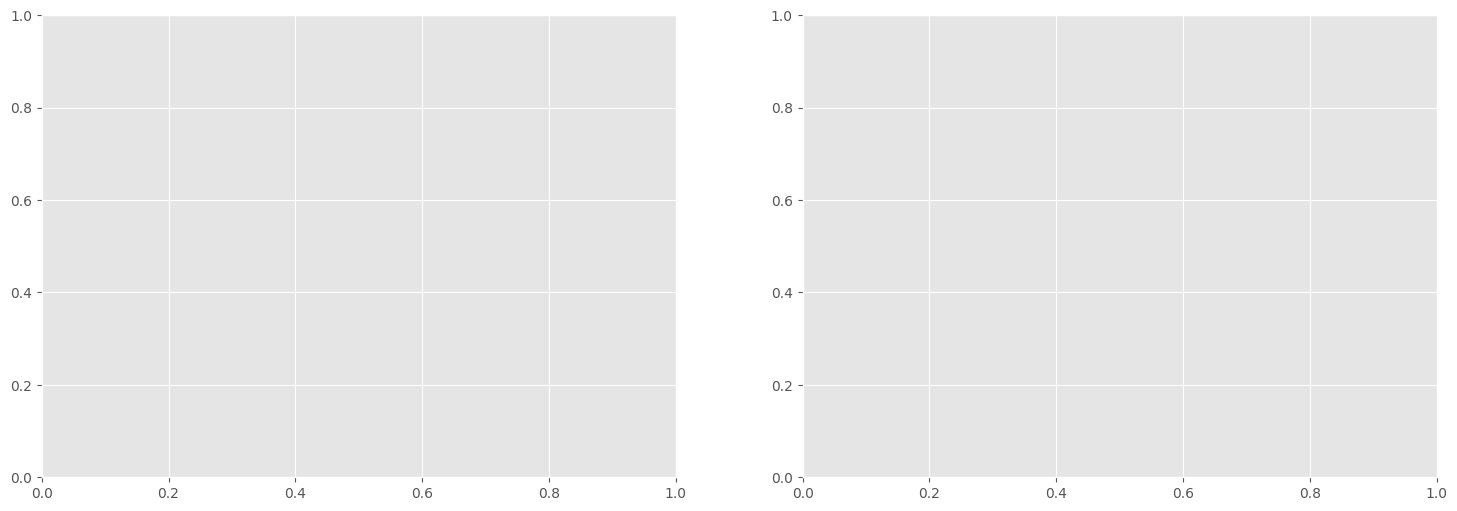

In [11]:
# visualizing the data setup 
fig, ax = plt.subplots(1,2, figsize = (18,6))

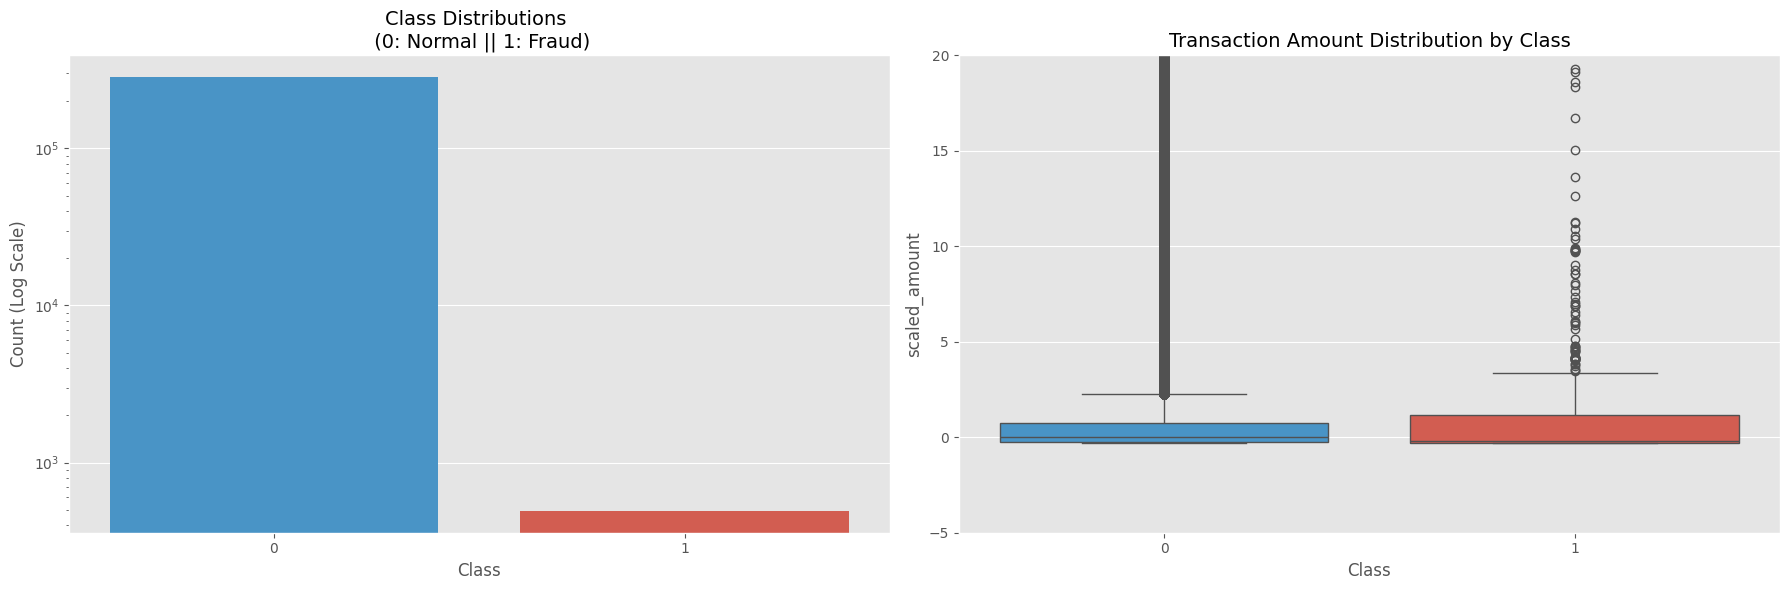

In [12]:
#plot 1: The class imbalance
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: The Class Imbalance
# Added hue='Class' and legend=False to resolve the FutureWarning
sns.countplot(x='Class', data=df, ax=ax[0], hue='Class', palette=['#3498db', '#e74c3c'], legend=False)
ax[0].set_title('Class Distributions \n (0: Normal || 1: Fraud)', fontsize=14)
ax[0].set_yscale('log') # Log scale helps visualize the tiny fraud bar
ax[0].set_ylabel('Count (Log Scale)')

# Plot 2: Distribution of Scaled Transaction Amounts by Class
# Added hue='Class' and legend=False to resolve the FutureWarning
sns.boxplot(x="Class", y="scaled_amount", data=df, ax=ax[1], hue='Class', palette=['#3498db', '#e74c3c'], legend=False)
ax[1].set_title('Transaction Amount Distribution by Class', fontsize=14)
ax[1].set_ylim(-5, 20) # Zooming in to bypass massive extreme outliers

plt.tight_layout()
plt.show()

In [13]:
from sklearn.model_selection import StratifiedShuffleSplit
from imblearn.over_sampling import SMOTE

In [14]:
# define features (X) and target (Y)
X = df.drop('Class', axis=1)
Y = df['Class']

In [15]:
# Stratified Train/Test split
#This ensures the 0.17% fraud ratio is preserved in both train and test sets
print('Splitting data (Stratified)...')
sss = StratifiedShuffleSplit( n_splits=1, test_size = 0.2, random_state=42)

for train_index, test_index in sss.split(X, Y):
    # Use .iloc to slice the dataframe safely
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    Y_train, Y_test = Y.iloc[train_index], Y.iloc[test_index]

Splitting data (Stratified)...


In [16]:
# Verify the split worked correctly
print("\n --- Split Verification ---")
print(f"Original Fraud Ration: {round(Y.value_counts()[1]/len(Y) * 100,3)}%")
print(f"Training Fraud Ratio: {round(Y_train.value_counts()[1]/len(Y_train) * 100, 3)}%")
print(f"Testing Fraud Ratio: {round(Y_test.value_counts()[1]/len(Y_test) * 100, 3)}%")


 --- Split Verification ---
Original Fraud Ration: 0.173%
Training Fraud Ratio: 0.173%
Testing Fraud Ratio: 0.172%


In [17]:
# Applying SMOTE to the Training data only 
print("\nApplying SMOTE to training data (This might take a moment)...")
smote = SMOTE(sampling_strategy='minority', random_state=42)

# X_sm and Y_sm are our new, balanced training datasets
X_sm, Y_sm = smote.fit_resample(X_train, Y_train)


Applying SMOTE to training data (This might take a moment)...


In [18]:
print("\n--- SMOTE Verification ---")
print(f"Before SMOTE, Normal (0): {Y_train.value_counts()[0]}, Fraud (1): {Y_train.value_counts()[1]}")
print(f"After SMOTE, Normal (0): {Y_sm.value_counts()[0]}, Fraud (1): {Y_sm.value_counts()[1]}")


--- SMOTE Verification ---
Before SMOTE, Normal (0): 227451, Fraud (1): 394
After SMOTE, Normal (0): 227451, Fraud (1): 227451


In [22]:
# Phase 4: Model Training and Evaluation

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, precision_recall_curve, auc, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
import xgboost as xgb

XGBoostError: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\n  Referenced from: <4E82201A-ED82-3451-AD25-7886C77941A1> /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/lib/libxgboost.dylib\n  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/O

In [ ]:
# Ensure you have the balanced training data (X_sm, Y_sm) 
# and the original imbalanced testing data (X_test, Y_test) from the previous step.

# 1. Train Baseline Logistic Regression
print("Training Logistic Regression (Baseline)...")
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_sm, Y_sm)

# Predict on the UNBALANCED test set
Y_pred_log = log_reg.predict(X_test)
Y_prob_log = log_reg.predict_proba(X_test)[:, 1]

# 2. Train Advanced XGBoost Model
print("Training XGBoost Classifier (This may take a moment)...")
xgb_clf = xgb.XGBClassifier(
    objective='binary:logistic',
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_clf.fit(X_sm, Y_sm)

# Predict on the UNBALANCED test set
y_pred_xgb = xgb_clf.predict(X_test)
y_prob_xgb = xgb_clf.predict_proba(X_test)[:, 1]

# 3. Evaluation Metrics Comparison
print("\n--- Logistic Regression Classification Report ---")
print(classification_report(Y_test, Y_pred_log))

print("\n--- XGBoost Classification Report ---")
print(classification_report(Y_test, Y_pred_xgb))

# 4. Visualize the Results

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Confusion Matrix for XGBoost
cm = confusion_matrix(Y_test, Y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0], 
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
ax[0].set_title('XGBoost Confusion Matrix', fontsize=14)
ax[0].set_ylabel('Actual')
ax[0].set_xlabel('Predicted')

# Plot B: Precision-Recall Curve Comparison
# Calculate PR curves
precision_log, recall_log, _ = precision_recall_curve(Y_test, Y_prob_log)
pr_auc_log = auc(recall_log, precision_log)

precision_xgb, recall_xgb, _ = precision_recall_curve(Y_test, Y_prob_xgb)
pr_auc_xgb = auc(recall_xgb, precision_xgb)

# Plot curves
ax[1].plot(recall_log, precision_log, label=f'Logistic Reg (PR-AUC = {pr_auc_log:.3f})', color='#3498db')
ax[1].plot(recall_xgb, precision_xgb, label=f'XGBoost (PR-AUC = {pr_auc_xgb:.3f})', color='#e74c3c', linewidth=2)
ax[1].set_title('Precision-Recall Curve Comparison', fontsize=14)
ax[1].set_xlabel('Recall (How much fraud did we catch?)')
ax[1].set_ylabel('Precision (When we flag fraud, are we right?)')
ax[1].legend(loc='lower left')

plt.tight_layout()
plt.show()